In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df= pd.read_excel("Desktop/UST Data Sample (July - Sept 2024).xlsx")

In [13]:
df.head(10)

,let me tak,Id,Client,RFQStatus,InstrumentSubGroup,Market Traded Vol (USD),Our Traded Vol,TiedWonVol,Num of Dealers,Trader,...,SettlementDays,SettlementDate,SettlementStops,RFQ CreateTime,RFQ ClosedTime,AnAutoReplyRFQs,First Response Time (Sec),TradeSizeBucket,Sector,MaturityBucket
0,2024-09-30,66FA7D45432800D20002,Client1,Done,OFFTHERUN,100000000,100000000,100000000,6,Trader1,...,1,2024-10-01,T+1,2024-09-30 06:28:00,2024-09-30 06:28:00,1,0.03,50+M,5-7 YR,5y-7y
1,2024-09-30,TRSY_20240930_15961,Client2,Done,"OFFTHERUN,DOUBLEOLDS",2100000,2100000,2100000,5,Trader2,...,1,2024-10-01,T+1,2024-09-30 16:00:00,2024-09-30 16:00:00,1,0.95,1-5M,7-10 YR,7y-10y
2,2024-09-30,TRSY_20240930_314,Client2,Done,ONTHERUN,53000000,53000000,53000000,5,Trader3,...,1,2024-10-01,T+1,2024-09-30 15:46:00,2024-09-30 15:46:00,1,0.07,50+M,7-10 YR,7y-10y
3,2024-09-30,66FAEA57432800020001,Client3,Done,OFFTHERUN,500000,500000,500000,5,Trader4,...,1,2024-10-01,T+1,2024-09-30 14:14:00,2024-09-30 14:14:00,1,0.03,500K-1M,0-1 YR,<18mos
4,2024-09-30,66FAC35D455C00210006,Client4,Done,OFFTHERUN,1058000,1058000,1058000,5,Trader2,...,1,2024-10-01,T+1,2024-09-30 11:27:00,2024-09-30 11:27:00,1,0.03,1-5M,5-7 YR,3y-5y
5,2024-09-30,66FB01C6432800130001,Client4,Done,ONTHERUN,25000000,25000000,0,5,Trader4,...,1,2024-10-01,T+1,2024-09-30 15:53:00,2024-09-30 15:54:00,0,13.28,25-50M,BILLS,<18mos
6,2024-09-30,66FAFF05432800000001,Client5,Done,ONTHERUN,1132000,1132000,0,1,Trader2,...,1,2024-10-01,T+1,2024-09-30 15:42:00,2024-09-30 15:42:00,1,0.03,1-5M,5-7 YR,5y-7y
7,2024-09-30,66FAEFC145C4000A0001,Client5,Done,ONTHERUN,818000,818000,0,1,Trader2,...,1,2024-10-01,T+1,2024-09-30 14:36:00,2024-09-30 14:36:00,1,0.03,500K-1M,7-10 YR,7y-10y
8,2024-09-30,66FA9F0D45C400400001,Client5,Done,ONTHERUN,500000,500000,0,1,Trader2,...,1,2024-10-01,T+1,2024-09-30 08:53:00,2024-09-30 08:53:00,1,0.03,500K-1M,3-5 YR,3y-5y
9,2024-09-30,66FB0D0C45C400000001,Client5,Done,ONTHERUN,500000,500000,500000,5,Trader2,...,1,2024-10-01,T+1,2024-09-30 16:41:00,2024-09-30 16:41:00,1,0.04,500K-1M,7-10 YR,7y-10y


In [14]:
missing_values = df.isnull().sum()
missing_values

let me tak                     0
Id                             0
Client                         0
RFQStatus                      0
InstrumentSubGroup             0
Market Traded Vol (USD)        0
Our Traded Vol                 0
TiedWonVol                     0
Num of Dealers                 0
Trader                         0
Sales                          0
Covered Vol                    0
ActionStr                      0
Tier                           0
InstrumentCode                 0
InstrumentDescription          0
AssetClass                     0
Market                         0
LegNo                          0
Maturity Date                  0
RFQNumberOfQuotes              0
Buy/Sell                       0
Best Bid Price                 0
Mid Price                      0
Best Ask Price                 0
Deal Value                     0
AwayFromMid                    0
TickIdentifier               445
Deal Spread                    0
Cover                          0
CoverPnL  

In [25]:
df.dropna(inplace=True)

Best Price Spread

In [27]:
# Create the relative features
data['Our Traded Volume Ratio'] = data['Our Traded Vol'] / data['Market Traded Vol (USD)']
data['Best Price Spread'] = (data['Best Ask Price'] - data['Best Bid Price']) / data['Mid Price']

# Analyze the new features: Descriptive statistics
relative_features_analysis = data[['Our Traded Volume Ratio', 'Best Price Spread']].describe()

relative_features_analysis

,Our Traded Volume Ratio,Best Price Spread
count,56319.0,65355.000000
mean,inf,-0.003821
std,NaN,0.039673
min,0.0,-2.000000
25%,0.0,-0.001914
50%,0.0,0.000077
75%,0.0,0.000197
max,inf,0.340322


In [29]:
# Create the relative features
data['Our Traded Volume Ratio'] = data['Our Traded Vol'] / data['Market Traded Vol (USD)']
data['Best Price Spread'] = (data['Best Ask Price'] - data['Best Bid Price']) / data['Mid Price']

# Analyze the new features: Descriptive statistics
relative_features_analysis = data[['Our Traded Volume Ratio', 'Best Price Spread']].describe()

relative_features_analysis


,Our Traded Volume Ratio,Best Price Spread
count,56319.0,65355.000000
mean,inf,-0.003821
std,NaN,0.039673
min,0.0,-2.000000
25%,0.0,-0.001914
50%,0.0,0.000077
75%,0.0,0.000197
max,inf,0.340322


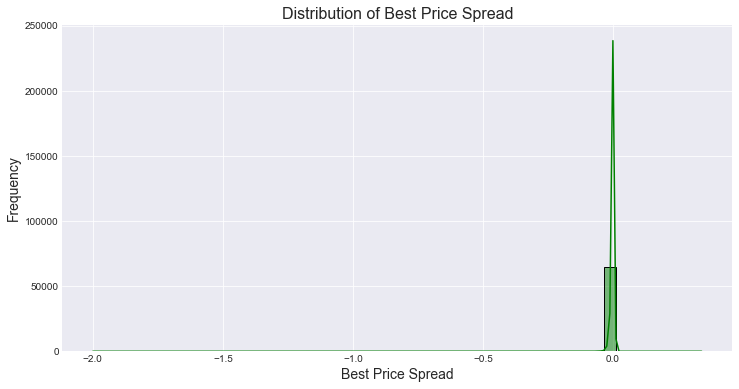

In [43]:
plt.figure(figsize=(12, 6))
sns.histplot(data['Best Price Spread'].dropna(), bins=50, color='green', kde=True)
plt.title('Distribution of Best Price Spread', fontsize=16)
plt.xlabel('Best Price Spread', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

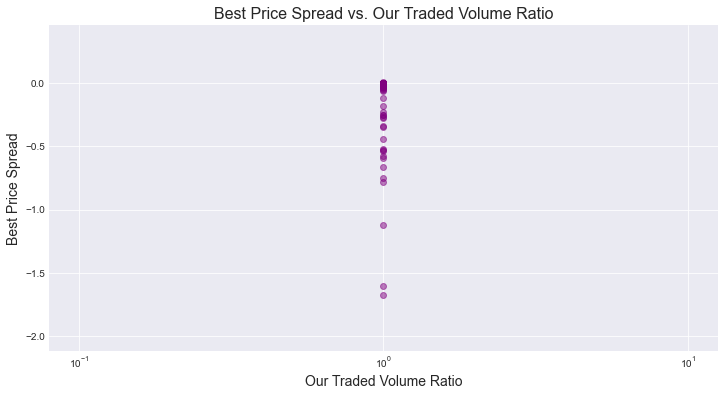

In [47]:
plt.figure(figsize=(12, 6))
plt.scatter(data['Our Traded Volume Ratio'], data['Best Price Spread'], alpha=0.5, color='purple')
plt.title('Best Price Spread vs. Our Traded Volume Ratio', fontsize=16)
plt.xlabel('Our Traded Volume Ratio', fontsize=14)
plt.ylabel('Best Price Spread', fontsize=14)
plt.xscale('log') 
plt.show()

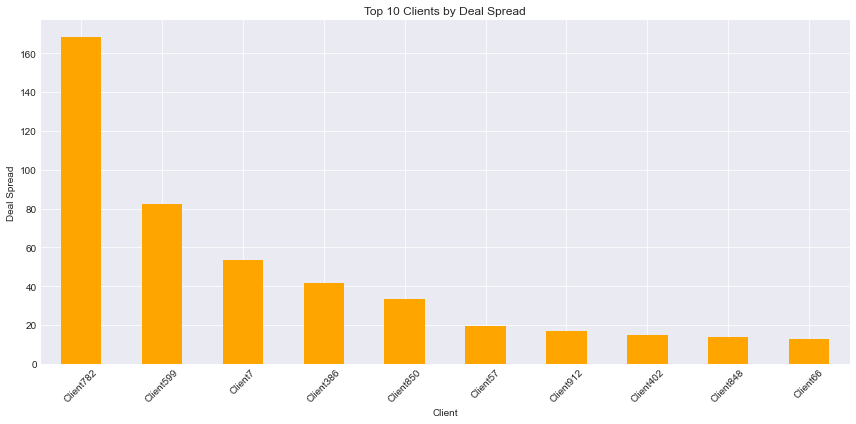

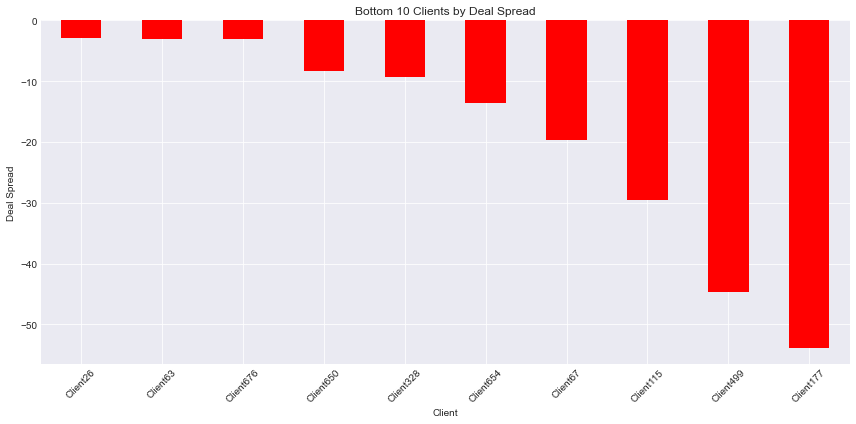

In [53]:
sorted_clients_spread = df.groupby('Client')['Deal Spread'].mean().sort_values(ascending=False)
top_clients_spread = sorted_clients_spread.head(10)
bottom_clients_spread = sorted_clients_spread.tail(10)

# Plot top clients by deal spread
plt.figure(figsize=(12, 6))
top_clients_spread.plot(kind='bar', title=f'Top {10} Clients by Deal Spread', color='orange')
plt.xlabel('Client')
plt.ylabel('Deal Spread')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot bottom clients by deal spread
plt.figure(figsize=(12, 6))
bottom_clients_spread.plot(kind='bar', title=f'Bottom {10} Clients by Deal Spread', color='red')
plt.xlabel('Client')
plt.ylabel('Deal Spread')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Time to First Response Ratio

/Users/jiangzixuan/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:4009: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


count    51979.0
mean         inf
std          NaN
min          0.0
25%          NaN
50%          NaN
75%          NaN
max          inf
Name: Time to First Response Ratio, dtype: float64


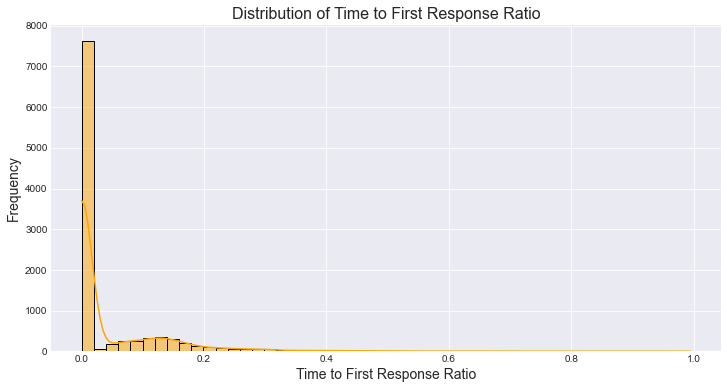

In [55]:
import pandas as pd

# Convert the 'RFQ CreateTime' and 'RFQ ClosedTime' to datetime, if not already done
data['RFQ CreateTime'] = pd.to_datetime(data['RFQ CreateTime'])
data['RFQ ClosedTime'] = pd.to_datetime(data['RFQ ClosedTime'])

# Calculate the Total RFQ Time in seconds
data['Total RFQ Time'] = (data['RFQ ClosedTime'] - data['RFQ CreateTime']).dt.total_seconds()

# Create the "Time to First Response Ratio" feature
data['Time to First Response Ratio'] = data['First Response Time (Sec)'] / data['Total RFQ Time']

# Analyze the new feature: Descriptive statistics
time_to_first_response_analysis = data['Time to First Response Ratio'].describe()

# Display the analysis
print(time_to_first_response_analysis)

# Plotting the distribution of the "Time to First Response Ratio"
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(data['Time to First Response Ratio'].dropna(), bins=50, color='orange', kde=True)
plt.title('Distribution of Time to First Response Ratio', fontsize=16)
plt.xlabel('Time to First Response Ratio', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()


/Users/jiangzixuan/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:4009: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


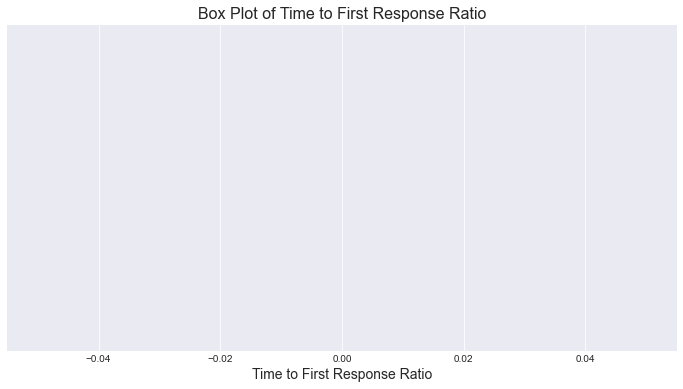

Time to First Response Ratio    1.000000
First Response Time (Sec)       0.969361
Market Traded Vol (USD)         0.235856
Our Traded Volume Ratio         0.118742
Our Traded Vol                  0.074343
Covered Vol                     0.054104
TiedWonVol                      0.027062
AwayFromMid                     0.011162
Deal Value                      0.010090
Deal Spread                     0.004778
Num of Dealers                 -0.017612
Cover                          -0.027724
Total RFQ Time                 -0.057517
LegNo                          -0.061927
Best Price Spread              -0.117182
SettlementDays                 -0.139495
Best Bid Price                 -0.224730
Mid Price                      -0.225408
Best Ask Price                 -0.226076
RFQNumberOfQuotes              -0.361369
AnAutoReplyRFQs                -0.692758
Name: Time to First Response Ratio, dtype: float64


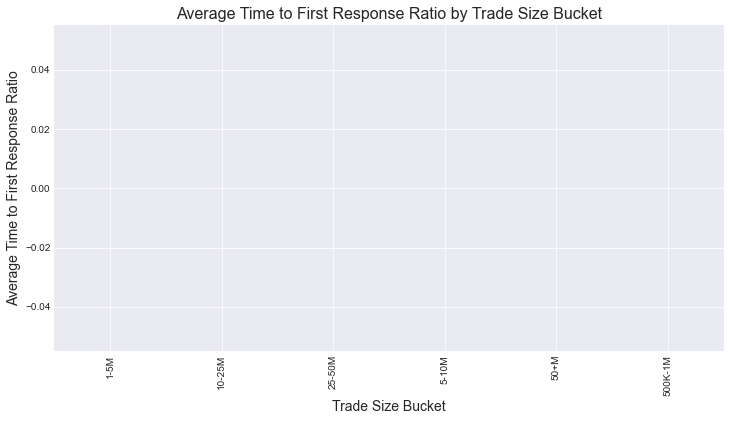

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Box Plot of "Time to First Response Ratio"
plt.figure(figsize=(12, 6))
sns.boxplot(x=data['Time to First Response Ratio'])
plt.title('Box Plot of Time to First Response Ratio', fontsize=16)
plt.xlabel('Time to First Response Ratio', fontsize=14)
plt.show()

# 2. Correlation Analysis
# Correlate "Time to First Response Ratio" with other numerical columns
correlation_matrix = data.corr()
time_to_response_correlation = correlation_matrix['Time to First Response Ratio'].sort_values(ascending=False)

# Display the top correlations
print(time_to_response_correlation)

# 3. Average "Time to First Response Ratio" by "Trade Size Bucket"
average_response_by_size = data.groupby('TradeSizeBucket')['Time to First Response Ratio'].mean().sort_values()

# Plot the average response time by trade size bucket
plt.figure(figsize=(12, 6))
average_response_by_size.plot(kind='bar', color='teal')
plt.title('Average Time to First Response Ratio by Trade Size Bucket', fontsize=16)
plt.xlabel('Trade Size Bucket', fontsize=14)
plt.ylabel('Average Time to First Response Ratio', fontsize=14)
plt.show()
